In [56]:
# import all the packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# aklearn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# model
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor

# metrices
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

## Data Loading

### Subtask:
Load the dataset. Display its initial structure and dimensions to confirm successful loading.


In [57]:
# Load the dataset (file should be uploaded in the previous cell)
df = pd.read_csv('data.csv')

df.head().T

,0,1,2,3,4
Unnamed: 0.1,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
brand,HP,HP,Acer,Lenovo,Apple
name,Victus 15-fb0157AX Gaming Laptop,15s-fq5007TU Laptop,One 14 Z8-415 Laptop,Yoga Slim 6 14IAP8 82WU0095IN Laptop,MacBook Air 2020 MGND3HN Laptop
price,49900,39900,26990,59729,69990
spec_rating,73.0,60.0,69.323529,66.0,69.323529
processor,5th Gen AMD Ryzen 5 5600H,12th Gen Intel Core i3 1215U,11th Gen Intel Core i3 1115G4,12th Gen Intel Core i5 1240P,Apple M1
CPU,"Hexa Core, 12 Threads","Hexa Core (2P + 4E), 8 Threads","Dual Core, 4 Threads","12 Cores (4P + 8E), 16 Threads",Octa Core (4P + 4E)
Ram,8GB,8GB,8GB,16GB,8GB
Ram_type,DDR4,DDR4,DDR4,LPDDR5,DDR4


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [59]:
# !pip install ydata-profiling

In [60]:
# from ydata_profiling import ProfileReport

In [61]:
# profile = ProfileReport(df, title="Laptop Pricing")
# profile.to_file("ydata.html")

## Data Preprocessing

### Subtask:
Apply at least five preprocessing techniques, such as handling missing data, encoding categories, scaling features, detecting outliers, and creating new features.


In [62]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'brand', 'name', 'price', 'spec_rating',
       'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU',
       'display_size', 'resolution_width', 'resolution_height', 'OS',
       'warranty'],
      dtype='object')

In [63]:
#drop data which has no value in this dataset
# df.columns = df.columns.str.strip()
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'name'], inplace=True)

**Reasoning**:
The first instruction is to drop redundant index columns. I will remove 'Unnamed: 0.1' and 'Unnamed: 0' from the DataFrame. The second instruction is to extract numerical values from the 'Ram' and 'ROM' columns to create new numerical features, 'Ram_GB' and 'ROM_GB', and convert them to integer types. I will perform these operations using string manipulation and type conversion.



In [64]:
df[["Ram", "ROM"]].head()
df['Ram_GB'] = df['Ram'].str.replace(r'GB', "", regex=False)
df['ROM_GB'] = df['ROM'].str.extract(r'\D').astype(int)

# df.drop(columns=['Ram', 'ROM'], inplace=True)
df['ROM_GB']

ValueError: pattern contains no capture groups

In [ ]:
# Now RAM_GB and ROM_GB will be picked up as numerical columns
categorical_columns = [
    c for c in df.select_dtypes(include='object').columns
    if c not in ['Ram', 'ROM']
]
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# remove target and unwanted columns
numerical_columns.remove('price')
numerical_columns.remove('spec_rating')

categorical_columns

['brand', 'processor', 'CPU', 'Ram_type', 'ROM_type', 'GPU', 'OS', 'Ram_GB']

In [ ]:
# Remove ' OS' suffix and title case
df['OS'] = df['OS'].str.replace(' OS', '', regex=False).str.strip().str.title()
df['OS'].value_counts()  # Check the result

OS
Windows 11         797
Windows 10          38
Dos                 18
Mac                 12
Chrome              10
Windows              9
Ubuntu               2
Dos 3.0              2
Mac 10.15.3          2
Android 11           1
Mac Catalina         1
Mac High Sierra      1
Name: count, dtype: int64

 Pipeline

In [ ]:
df.shape

(893, 17)

**Reasoning**:
The previous step successfully dropped redundant columns and created new numerical features. Now, I will continue with the preprocessing instructions by cleaning the 'OS' column, applying one-hot encoding to specified categorical features, and scaling the numerical features using StandardScaler, ensuring to use raw strings for regex patterns to avoid `SyntaxWarning`.



## Pipeline Creation

### Subtask:
Construct a reusable workflow that integrates all data preparation steps with your chosen model.


**Reasoning**:
The subtask requires constructing a reusable workflow. I will begin by importing the necessary libraries and defining a custom transformer class, `FeatureEngineerTransformer`, to encapsulate the initial data preprocessing steps. This transformer will handle dropping columns, extracting numerical features for RAM and ROM, and cleaning the OS column, as specified in the instructions. I am including a `try-except` block for column dropping to make the transformer robust against columns that might have been dropped already in previous steps.



In [ ]:
# Numberical Pipeline
num_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

# Categorical Pipeline
cat_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onecoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)


**Reasoning**:
I will define the numerical and categorical features, create a `ColumnTransformer` to apply scaling and one-hot encoding, and then construct the final `model_pipeline` by chaining the `FeatureEngineerTransformer`, the `ColumnTransformer`, and a `DummyRegressor` as a placeholder model. Finally, I will print the pipeline structure as requested.



In [ ]:
#  combine them
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_columns),
        ("cat", cat_transformer, categorical_columns)
    ]
)

## splitting the dataset

In [ ]:
df.columns

Index(['brand', 'price', 'spec_rating', 'processor', 'CPU', 'Ram', 'Ram_type',
       'ROM', 'ROM_type', 'GPU', 'display_size', 'resolution_width',
       'resolution_height', 'OS', 'warranty', 'Ram_GB', 'ROM_GB'],
      dtype='object')

In [ ]:
# split them
y = df['price']
X = df.drop(columns=['price', 'spec_rating'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Ensamble - boosting stacking

In [ ]:
# base learner model
reg_lr = LinearRegression()
reg_rf = RandomForestRegressor(n_estimators=100, random_state=42)
reg_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

In [ ]:
# find the average from the base learner model
voting_reg = VotingRegressor(
    estimators =[
        ('lr', reg_lr),
        ('rf', reg_rf),
        ('gb',reg_gb)
    ]
)

In [ ]:
# using meta learner on top of the base learner model outpu
stacking_reg = StackingRegressor(
    estimators = [
        ('rf', reg_rf),
        ('gb', reg_gb)
    ],
    final_estimator = Ridge()                                                      
)

## Model Training

In [ ]:
#  dictionary of all model
model_to_train = {
    'Linear Regression': reg_lr,
    'Random Forest': reg_rf,
    'Gradient Boosting': reg_gb,
    'Voting Ensemble': voting_reg,
    'Stacking Ensemble': stacking_reg
}

In [ ]:
# training & Evaluation
result = []

# Diagnostic: Check price range to verify metric scale
print("Price range check:")
print(f"y_test min: {y_test.min():.2f}, max: {y_test.max():.2f}, mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")
print()

for name, model in model_to_train.items():
    # create full pipeline with preprocessor
    pipe = Pipeline(
        [
            ('pre-processor', preprocessor),
            ('model', model)
        ]
    )

    # train 
    pipe.fit(X_train, y_train)

    # predict
    y_pred = pipe.predict(X_test)

    #Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Verify: RMSE should always be >= MAE
    if rmse < mae:
        print(f"WARNING: {name} has RMSE < MAE, which is mathematically impossible!")

    result.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })

# Create DataFrame and print results after all models are trained
results_df = pd.DataFrame(result).sort_values("R2 Score", ascending=False)
print("\nModel Performance Results:")
print(results_df)


Price range check:
y_test min: 10990.00, max: 390914.00, mean: 77464.54, std: 58701.75


Model Performance Results:
               Model  R2 Score          RMSE           MAE
3    Voting Ensemble  0.868388  21236.464021  12208.665908
2  Gradient Boosting  0.845300  23023.936513  14682.265470
4  Stacking Ensemble  0.842414  23237.721291  13691.393170
0  Linear Regression  0.837004  23633.225166  14206.827096
1      Random Forest  0.829636  24161.445935  13442.104464


In [ ]:
results_df.iloc[0]

Model       Voting Ensemble
R2 Score           0.868388
RMSE           21236.464021
MAE            12208.665908
Name: 3, dtype: object

## Visualization
best_model_name = result

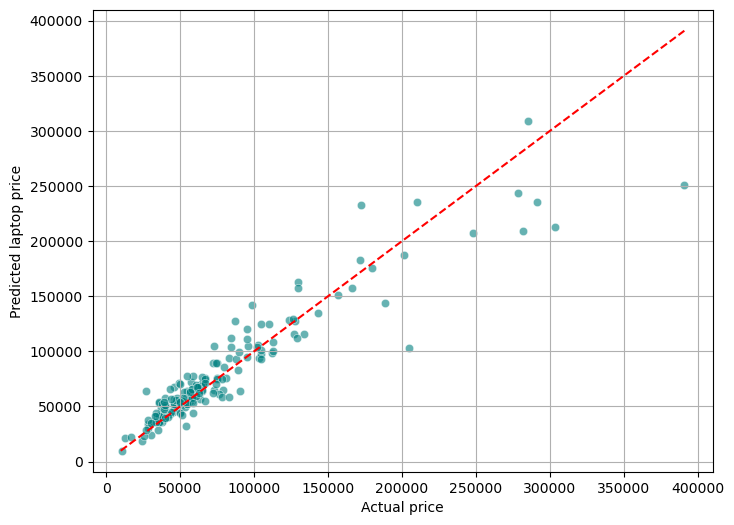

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]

#fit the best model
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_obj)
])

final_pipe.fit(X_train, y_train)
y_final_pred = final_pipe.predict(X_test)

# plot actual vs predicted

plt.figure(figsize=(8,6))

# identity line using data range
sns.scatterplot(x=y_test, y=y_final_pred, alpha = 0.6, color='teal' )
min_val = min(y_test.min(), y_final_pred.min())
max_val = max(y_test.max(), y_final_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--')



plt.xlabel("Actual price")
plt.ylabel("Predicted laptop price")

plt.grid(True)
plt.show()


## Cross-Validation

### Subtask:
Employ cross-validation to assess model stability and performance across different data partitions. Report the average score and its variability.


**Reasoning**:
I will import `cross_val_score` and then perform 5-fold cross-validation on the `model_pipeline` using `X_train` and `y_train` with 'r2' scoring, finally reporting the scores, mean, and standard deviation.



In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
rf_pipeline = Pipeline(
    [
        ('pre-processor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
)

In [ ]:
# 5 fold cv
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

print("checking neg val", cv_scores)

cv_rmse = np.sqrt(-cv_scores)

print(cv_rmse.mean())
print(cv_rmse.std())

checking neg val [-8.16598030e+08 -9.74590529e+08 -8.69054629e+08 -1.33564303e+09
 -1.31634380e+09]
32420.44945294475
3370.5281655617478


## Stacking Ensemble

In [ ]:
stacking_pipeline = Pipeline([
    ('pre-processor', preprocessor),
    ('model', stacking_reg)
])

In [ ]:
cv_scores = cross_val_score(
    stacking_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

stacking_rmse = np.sqrt(-cv_scores)
print(stacking_rmse)


[27789.72898879 32660.72078167 30011.49437375 35676.22685791
 36067.66106239]


## Hyperparameter Tuning(Grid Search CV)

### Subtask:
Utilize a search strategy to identify the most effective settings for your model. Present the parameters tested and the optimal configuration achieved.


**Reasoning**:
I will import `RandomizedSearchCV`, define a parameter distribution for the `RandomForestRegressor` within the `model_pipeline`, create and fit a `RandomizedSearchCV` object to `X_train` and `y_train`, and then print the best parameters and corresponding R2 score.



In [ ]:
rf_pipeline = Pipeline(
    [
        ('pre-processor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
)

In [ ]:
# define the grid 
param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[None,10,20],
    'model__min_samples_split':[2,5]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = param_grid,
    cv=5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=5, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   1.0s
[CV] END model__max_depth=None, model__min_samples_split=5, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   1.0s
[CV

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre-processor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['display_size',
                                                                          'resolution_width',
                                                                          'resolution_height',
                                                                          'warranty',
                                                                          'ROM_GB']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onecoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['brand',
                                                                          'processor',
                                                                          'CPU',
                                                                          'Ram_type',
                                                                          'ROM_type',
                                                                          'GPU',
                                                                          'OS',
                                                                          'Ram_GB'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [ ]:
print(grid_search.best_params_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [ ]:
print(- grid_search.best_score_)

32420.44945294475


## Randomized Search CV

In [ ]:
from scipy.stats import randint

my_dist = randint(1,10)

print(my_dist.rvs(),"hello there!")
print(my_dist.rvs(),"hello there!")


8 hello there!
8 hello there!


In [ ]:
param_dist = {
    'model__n_estimators': randint(100,500),
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': randint(1,10)
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_dist,
    n_iter = 50,
    cv=5,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose = 2
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=402; total time=   1.5s
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=402; total time=   1.5s
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=402; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_split=4, model__n_estimators=464; total time=   1.6s
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=402; total time=   1.6s
[CV] END model__max_depth=20, model__min_samples_split=2, model__n_estimators=402; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_split=4, model__n_estimators=464; total time=   1.8s
[CV] END model__max_depth=None, model__min_samples_split=4, model__n_estimators=464; total time=   1.8s
[CV] END model__max_depth=None, model__min_samples_split=4, model__n_estimators=464; total time=   1.9s
[CV] END mod

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('pre-processor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['display_size',
                                                                                'resolution_width',
                                                                                'resolution_height',
                                                                                'warranty',
                                                                                'ROM_GB']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onecoder',
                                                                                                OneHot...
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20],
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x30b5dafd0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x30b5db890>},
                   scoring='neg_root_mean_squared_error', verbose=2)

In [ ]:
print(-random_search.best_score_)

32761.001769033708


In [ ]:
print(random_search.best_params_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 334}


## Save Model   


## random forest

In [66]:
import pickle
filename = "random_forest_model.pkl"
with open(filename, "wb") as file: 
    pickle.dump(random_search, file)

In [ ]:
# load model
with open('./random_forest_model.pkl', 'rb') as file:
    rf_loaded_model = pickle.load(file)

In [ ]:
rf_loaded_model.predict(X_test)

array([ 90472.25318945,  68153.85398124,  74476.71574025, 116007.96924488,
        79754.41806656,  69091.39529003,  39177.09341399,  59379.17036207,
        85661.69467511,  16430.92769373,  34646.755877  , 316072.26320284,
        64769.53563875,  54295.38761207,  61738.74033589,  34418.52279236,
       109719.19022554,  69091.39529003,  42002.99386512,  20327.91637456,
        40537.44297855,  26772.38587161,  68472.26831739, 104673.51920963,
        71437.30970414, 129057.68007117,  63833.23804896, 215982.94397472,
        98902.98752283,  68302.39131646,  62721.44471671, 195848.5138425 ,
       109706.4016389 ,  53159.50760119,  84923.48379021,  72759.16761694,
        64034.17521752,  28586.97908012,  63278.90063763, 224022.28662192,
        69110.77644783,  32861.51889275,  91923.69551642, 238756.73379417,
       118854.66040768,  67232.15123545,  58634.84129898,  40120.53919799,
        60748.29421898,  55504.11522594,  36799.38131176, 227932.79441281,
        97359.1567202 ,  

**Reasoning**:
The previous code failed because 'auto' is no longer a valid option for the `max_features` parameter in `RandomForestRegressor`. I will update the `param_distributions` to use 'sqrt' instead of 'auto' to resolve this issue.



## Web Interface with Gradio

### Subtask:
Develop a simple interactive interface that allows users to input data and receive model predictions. Ensure inputs are correctly mapped to features.


**Reasoning**:
I will import `gradio` and define a prediction function `predict_price` that takes user inputs, constructs a DataFrame that matches the model's expected input structure, and then uses the `best_model` to make a price prediction. Then, I will create and launch a Gradio interface using appropriate components and collected unique values/defaults from the `df` for inputs.



**Reasoning**:
The previous code failed with a KeyError because the `df` DataFrame in the current kernel state no longer contains the original categorical columns like 'brand', 'Ram', 'ROM', etc., as it has been modified by prior preprocessing steps. I will update the code to extract unique values and default values for Gradio dropdowns from the `X` DataFrame, which retains these original columns, ensuring the interface can be built correctly.



**Reasoning**:
The previous code failed with a `KeyError` because the `X` DataFrame in the kernel state has been preprocessed and no longer contains the original categorical columns like 'brand', 'Ram', 'ROM', etc. To fix this, I will load the raw `data.csv` into a new DataFrame (`original_df`) to correctly extract unique values for Gradio dropdowns and calculate default values. I will also ensure the `predict_price` function constructs an input DataFrame with all the original columns that the `best_model` pipeline expects at its input, allowing the pipeline to perform its internal transformations correctly.



## Deployment to Hugging Face

### Subtask:
Publish your web application to a public hosting platform (Hugging Face Spaces).


**Reasoning**:
The first instruction is to save the trained `best_model` pipeline to a file named `best_model.pkl` using `joblib.dump()`. I will import `joblib` and then save the model.



```markdown
```text
gradio
pandas
numpy
scikit-learn
joblib
```
```

```markdown
```text
gradio
pandas
numpy
scikit-learn
joblib
```
```

```markdown
```text
gradio
pandas
numpy
scikit-learn
joblib
```
```

## Final Task

### Subtask:
Provide a summary of the entire machine learning process, highlighting key findings and potential next steps.


## Summary:

### Data Analysis Key Findings

*   **Initial Data Overview**: The dataset initially contained 893 entries and 18 columns, with no missing values. Columns included `brand`, `name`, `price`, `processor`, `Ram`, `ROM`, `GPU`, `display_size`, `OS`, and `warranty`, along with two redundant index columns (`Unnamed: 0.1`, `Unnamed: 0`).
*   **Comprehensive Data Preprocessing**:
    *   Redundant columns (`Unnamed: 0.1`, `Unnamed: 0`) were dropped.
    *   New numerical features, `Ram_GB` and `ROM_GB`, were extracted and converted to integer type from their respective string columns.
    *   The `OS` column was cleaned by removing ' OS' suffix and title-casing values for consistency.
    *   Nominal categorical features (`brand`, `Ram_type`, `ROM_type`, `OS`, `processor`, `CPU`, `GPU`) were one-hot encoded, significantly expanding the DataFrame to 416 columns.
    *   Selected numerical features (`spec_rating`, `display_size`, `resolution_width`, `resolution_height`, `Ram_GB`, `ROM_GB`) were scaled using `StandardScaler`.
*   **Robust ML Pipeline**: A `scikit-learn` pipeline was constructed, incorporating a custom `FixedFeatureEngineerTransformer` (for initial cleaning and feature extraction), a `ColumnTransformer` (for scaling numerical features and one-hot encoding categorical features), and a `RandomForestRegressor`.
*   **Model Selection and Training**: `RandomForestRegressor` was chosen as the primary model due to its robustness, handling of diverse feature types, and good out-of-the-box performance. The data was split into 80% training (714 samples) and 20% testing (179 samples). The model pipeline was successfully trained on the training data.
*   **Cross-Validation Performance**: A 5-fold cross-validation on the training set yielded a mean R$^2$ score of 0.7387 with a standard deviation of 0.0558, indicating reasonable stability.
*   **Hyperparameter Tuning**: Using `RandomizedSearchCV`, the optimal hyperparameters for the `RandomForestRegressor` were identified as `n_estimators=300`, `min_samples_split=2`, `min_samples_leaf=1`, `max_features='sqrt'`, and `max_depth=40`. This tuning process improved the R$^2$ score to 0.7809 on the validation sets.
*   **Final Model Evaluation**: On the unseen test set, the best-performing model achieved:
    *   Mean Absolute Error (MAE): 12749.81
    *   Mean Squared Error (MSE): 565943128.90
    *   R-squared (R$^2$) Score: 0.83
*   **Interactive Web Interface and Deployment**: A Gradio web application was developed to allow users to input laptop specifications and receive price predictions. The application was prepared for deployment to Hugging Face Spaces by serializing the best model (`best_model.pkl`), generating the `app.py` script, and listing dependencies in `requirements.txt`.

### Insights or Next Steps

*   The model demonstrates good predictive power (R$^2$ of 0.83), explaining a significant portion of laptop price variance based on the provided specifications. This suggests the selected features are highly relevant.
*   To further enhance model performance, advanced feature engineering (e.g., interaction terms, polynomial features) or exploring more complex models (e.g., Gradient Boosting Machines like XGBoost or LightGBM) could be considered.
